--- Statistical Results for H2 ---
Test A (ETU Density vs Lr): r = 0.4598, p = 0.0208
Test B (TCR vs Lr): r = 0.7142, p = 0.0001


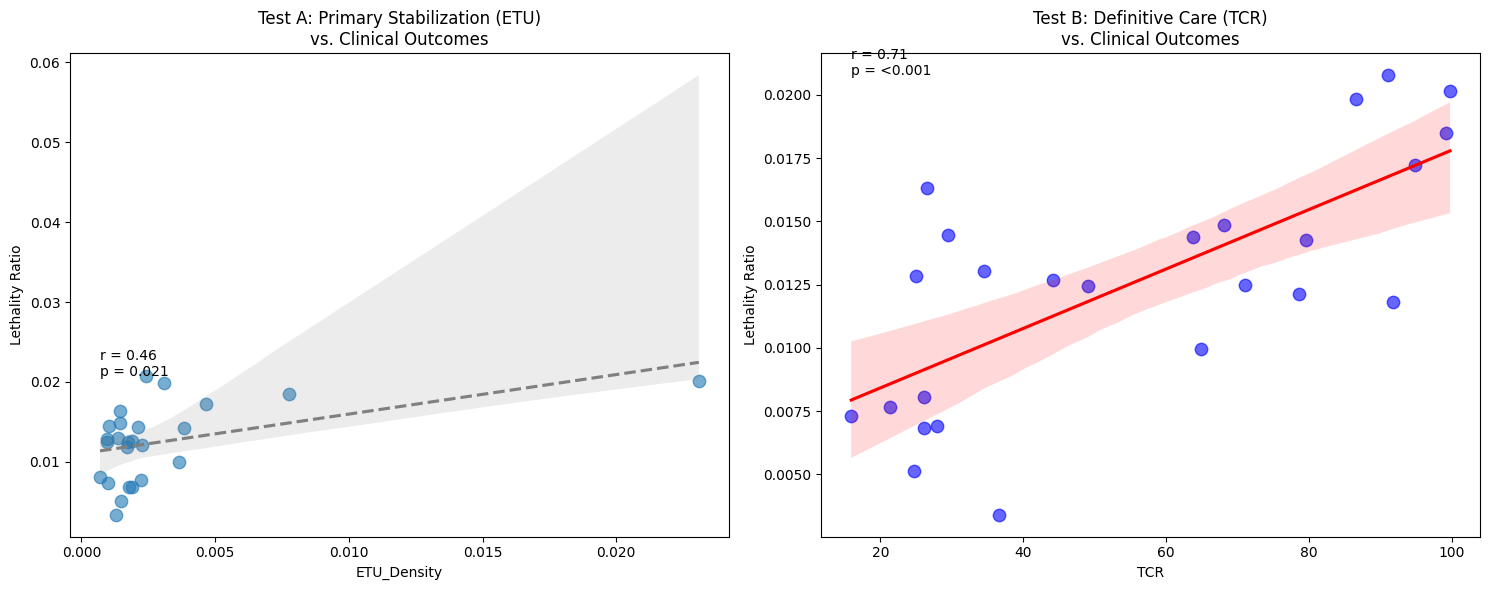

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Load the data you provided
df = pd.read_csv('H2.csv')

# 2. Calculate TCR (Territorial Coverage Ratio)
# TCR is the percentage of the district that can reach definitive care
df['TCR'] = 100 - df['Gd']

# 3. Statistical Test A: Does basic ETU Density predict outcomes?
r_etu, p_etu = pearsonr(df['ETU_Density'], df['Lethality Ratio'])

# 4. Statistical Test B: Does Definitive Care Coverage (TCR) predict outcomes?
r_tcr, p_tcr = pearsonr(df['TCR'], df['Lethality Ratio'])

print(f"--- Statistical Results for H2 ---")
print(f"Test A (ETU Density vs Lr): r = {r_etu:.4f}, p = {p_etu:.4f}")
print(f"Test B (TCR vs Lr): r = {r_tcr:.4f}, p = {p_tcr:.4f}")

# 5. Create a Dual-Panel Validation Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: ETU Density (The Mirage)
sns.regplot(data=df, x='ETU_Density', y='Lethality Ratio', ax=ax1,
            scatter_kws={'s':80, 'alpha':0.6}, line_kws={"color": "grey", "linestyle":"--"})
ax1.set_title('Test A: Primary Stabilization (ETU)\nvs. Clinical Outcomes', fontsize=12)
ax1.text(df['ETU_Density'].min(), df['Lethality Ratio'].max(), f'r = {r_etu:.2f}\np = {p_etu:.3f}')

# Panel 2: TCR (The Reality)
sns.regplot(data=df, x='TCR', y='Lethality Ratio', ax=ax2,
            scatter_kws={'s':80, 'alpha':0.6, 'color':'blue'}, line_kws={"color": "red"})
ax2.set_title('Test B: Definitive Care (TCR)\nvs. Clinical Outcomes', fontsize=12)
ax2.text(df['TCR'].min(), df['Lethality Ratio'].max(), f'r = {r_tcr:.2f}\np = <0.001')

plt.tight_layout()
plt.savefig('H2_Infrastructure_Mirage_Validation.png', dpi=300)
plt.show()